# ISTAT TRAFFIC DATA ANALYSIS - ANALYSIS

In [54]:
# import packages
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# set style for plots
sns.set_style("whitegrid")

In the `data_preparation.ipynb` notebook, we cleaned, fixed, and joined the data from the INSTAT and SITUAS databases. Now, let's analyze this data to extract useful information about road accidents that occurred between 2001 and 2024. We will examine how these accidents changed over time and how they were affected by population growth in those cities.

In [55]:
# import data
# -> Use keep_default_na to avoid issues with misunderstood values as before (since now we know what to expect)

df_raw = pd.read_csv('data/instat_situas_traffic_accidents_data.csv', keep_default_na=False)

print(df_raw.info())
df_raw.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572700 entries, 0 to 572699
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          572700 non-null  object 
 1   FREQ              572700 non-null  object 
 2   REF_AREA          572700 non-null  int64  
 3   DATA_TYPE         572700 non-null  object 
 4   RESULT            572700 non-null  object 
 5   TIME_PERIOD       572700 non-null  int64  
 6   OBS_VALUE         572700 non-null  int64  
 7   Comune            572700 non-null  object 
 8   Provincia         572700 non-null  object 
 9   Codice Regione    572700 non-null  object 
 10  Residenti         572700 non-null  float64
 11  Superficie (Kmq)  572700 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 52.4+ MB
None


,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Comune,Provincia,Codice Regione,Residenti,Superficie (Kmq)
501747,IT1:41_983(1.0),A,87047,ROADACC,9,2019,12,Santa Maria di Licodia,CT,Sicilia,7457.0,26.2767
166866,IT1:41_983(1.0),A,18016,KILLINJ,F,2004,2,Borgo Priolo,PV,Lombardia,1388.0,28.8094
506549,IT1:41_983(1.0),A,90027,KILLINJ,F,2015,0,Cossoine,SS,Sardegna,851.0,39.1704
1567,IT1:41_983(1.0),A,1023,KILLINJ,F,2014,0,Barone Canavese,TO,Piemonte,580.0,3.9864
558414,IT1:41_983(1.0),A,103019,ROADACC,9,2007,17,Casale Corte Cerro,VB,Piemonte,3524.0,12.5227
268450,IT1:41_983(1.0),A,33002,KILLINJ,M,2011,0,Alseno,PC,Emilia-Romagna,4871.0,55.2695
67321,IT1:41_983(1.0),A,6096,KILLINJ,M,2012,0,Molino dei Torti,AL,Piemonte,663.0,2.7527
459663,IT1:41_983(1.0),A,78087,KILLINJ,F,2022,0,Oriolo,CS,Calabria,1834.0,85.6014
362522,IT1:41_983(1.0),A,61045,ROADACC,9,2005,0,Liberi,CE,Campania,1183.0,17.5891
369074,IT1:41_983(1.0),A,62033,KILLINJ,M,2022,0,Fragneto l'Abate,BN,Campania,958.0,20.5737


Let's rename some columns to help us with the analysis

In [56]:
# selecting only useful columns:
features_analysis = df_raw.columns[3:]
df = df_raw[features_analysis].copy()

df.rename(columns={
    'DATA_TYPE': 'Accident Category',
    'RESULT': 'Type',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'Value',
    'Comune': 'City',
    'Provincia': 'Province',
    'Codice Regione': 'Region',
    'Residenti': 'Residents',
    'Superficie (Kmq)': 'Area (km2)'
    },
    inplace=True
)

df.sample(5)

,Accident Category,Type,Year,Value,City,Province,Region,Residents,Area (km2)
406160,ROADACC,9,2011,0,Villavallelonga,AQ,Abruzzo,946.0,73.7329
217743,ROADACC,9,2016,8,Gazzo Veronese,VR,Veneto,5339.0,56.6542
454954,KILLINJ,M,2023,0,Buonvicino,CS,Calabria,1992.0,30.5944
455600,KILLINJ,F,2009,2,Castiglione Cosentino,CS,Calabria,3025.0,13.9477
443442,ROADACC,9,2022,3,Tiggiano,LE,Puglia,2762.0,7.7103


Working with this type of data structure can be difficult. It would be much easier if we had only one row (record) for each city and year instead of three.    
To do that we can pivot the table to create three new columns for fatalities, injuries, and collisions with the respective values.  
By doing this, we can neglect the columns for `Accident Category`. Meanwhile, the values for `Type` are transformed into new columns.

In [57]:
# PIVOT TABLE

df_pivot = df.pivot_table(
    index=['Year', 'City', 'Province', 'Region', 'Residents', 'Area (km2)'],
    columns='Type',
    values='Value',
    fill_value=0,
).reset_index()

# Rename columns for clarity
df_pivot = df_pivot.rename(columns={
    '9': 'Collisions',
    'F': 'Injuries',
    'M': 'Fatalities'
    }
)

df_pivot

Type,Year,City,Province,Region,Residents,Area (km2),Collisions,Injuries,Fatalities
0,2001,Abano Terme,PD,Veneto,18177.0,21.4376,79.0,105.0,0.0
1,2001,Abbadia Cerreto,LO,Lombardia,275.0,6.1986,1.0,2.0,0.0
2,2001,Abbadia Lariana,LC,Lombardia,3146.0,16.6703,28.0,44.0,0.0
3,2001,Abbadia San Salvatore,SI,Toscana,6824.0,58.9933,24.0,34.0,2.0
4,2001,Abbasanta,OR,Sardegna,2814.0,39.8469,12.0,15.0,1.0
...,...,...,...,...,...,...,...,...,...
190895,2024,Zubiena,BI,Piemonte,1125.0,12.4739,6.0,6.0,0.0
190896,2024,Zuccarello,SV,Liguria,279.0,10.8070,4.0,4.0,0.0
190897,2024,Zugliano,VI,Veneto,6901.0,13.7300,3.0,4.0,0.0
190898,2024,Zumpano,CS,Calabria,2603.0,8.0838,5.0,9.0,1.0


As you can see, the rows are now 1/3 the size of the original. We can now proceed by calculating some useful metrics for our analysis:
1) **Total Accidents:** total number of accidents 
2) **Harmful Accidents:** total number of accidents that caused deaths or injuries
3) **Severity Index:** ratio of fatal (M) and serious (F) accidents divided by the total. This metric helps us to calculate how much dangerous the roads are
4) **Fatality Rate:** ratio of fatal accidents divided by the total
5) **Per-Capita Accident Rate (per 10,000 residents):** ratio of accidents per 10,000 residents. This helps us avoid biased values for cities with large populations and it also indicates the number of accidents for every 10,000 inhabitants.
6) **Collision Density:** ratio of total accidents divided by the area (km2)

In [58]:
# check min values for division
print(df_pivot['Area (km2)'].min(), df_pivot['Residents'].max())

0.1206 2820219.0


In [59]:
# 1) Total Accidents
df_pivot['Total_Accidents'] = df_pivot['Collisions'] + df_pivot['Injuries'] + df_pivot['Fatalities']

# 2) Harmful Accidents (M + F)
df_pivot['Harmful_Accidents'] = df_pivot['Fatalities'] + df_pivot['Injuries']

# 3) Severity Index (where condition to taking into account possible division by zero)
df_pivot['Severity_index'] = np.where(df_pivot['Total_Accidents'] > 0, df_pivot['Harmful_Accidents'] / df_pivot['Total_Accidents'], 0,)

# 4) Fatality Rate
df_pivot['Fatality_Rate'] = np.where(df_pivot['Total_Accidents'] > 0, df_pivot['Fatalities'] / df_pivot['Total_Accidents'], 0,)

# 5) Per-Capita Accidents Rate
df_pivot['Per_Capita_Accidents_Rate'] = (df_pivot['Total_Accidents'] / df_pivot['Residents']) * 1e4

# 6) Collision Density
df_pivot['Collision_Density'] = df_pivot['Total_Accidents'] / df_pivot['Area (km2)']

df_pivot


Type,Year,City,Province,Region,Residents,Area (km2),Collisions,Injuries,Fatalities,Total_Accidents,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
0,2001,Abano Terme,PD,Veneto,18177.0,21.4376,79.0,105.0,0.0,184.0,105.0,0.570652,0.000000,101.226825,8.583050
1,2001,Abbadia Cerreto,LO,Lombardia,275.0,6.1986,1.0,2.0,0.0,3.0,2.0,0.666667,0.000000,109.090909,0.483980
2,2001,Abbadia Lariana,LC,Lombardia,3146.0,16.6703,28.0,44.0,0.0,72.0,44.0,0.611111,0.000000,228.862047,4.319058
3,2001,Abbadia San Salvatore,SI,Toscana,6824.0,58.9933,24.0,34.0,2.0,60.0,36.0,0.600000,0.033333,87.924971,1.017065
4,2001,Abbasanta,OR,Sardegna,2814.0,39.8469,12.0,15.0,1.0,28.0,16.0,0.571429,0.035714,99.502488,0.702690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190895,2024,Zubiena,BI,Piemonte,1125.0,12.4739,6.0,6.0,0.0,12.0,6.0,0.500000,0.000000,106.666667,0.962009
190896,2024,Zuccarello,SV,Liguria,279.0,10.8070,4.0,4.0,0.0,8.0,4.0,0.500000,0.000000,286.738351,0.740261
190897,2024,Zugliano,VI,Veneto,6901.0,13.7300,3.0,4.0,0.0,7.0,4.0,0.571429,0.000000,10.143457,0.509832
190898,2024,Zumpano,CS,Calabria,2603.0,8.0838,5.0,9.0,1.0,15.0,10.0,0.666667,0.066667,57.625816,1.855563


Let's also create another data frame that takes the entire time span and sums all the accident values. For the area we will take the mean values across the years since Mmnicipal boundaries rarely change in Italy.  
On the other hand, for the number of residents, it is better to take the total number across the time span, since we are summing the total number of accidents. If we need to calculate the per capita rate, it is more correct to calculate it by dividing the total number of accidents by the total number of residents.

In [60]:
df_pivot_24y = df_pivot.groupby(['City', 'Province', 'Region']).agg(
                                                                    Sum_Residents_Years=('Residents', 'sum'),
                                                                    Mean_Area_km2=('Area (km2)', 'mean'),
                                                                    Total_Collisions=('Collisions', 'sum'),
                                                                    Total_Fatalities=('Fatalities', 'sum'),
                                                                    Total_Injuries=('Injuries', 'sum'),
                                                                    Total_Accidents=('Total_Accidents', 'sum'),
                                                                    Years_Recorded=('Year', 'count'),
                                                                    ).reset_index()


# calculcate again the metrics
# 2) Harmful Accidents (M + F)
df_pivot_24y['Harmful_Accidents'] = df_pivot_24y['Total_Fatalities'] + df_pivot_24y['Total_Injuries']

# 3) Severity Index (where condition to taking into account possible division by zero)
df_pivot_24y['Severity_index'] = np.where(df_pivot_24y['Total_Accidents'] > 0, df_pivot_24y['Harmful_Accidents'] / df_pivot_24y['Total_Accidents'], 0,)

# 4) Fatality Rate
df_pivot_24y['Fatality_Rate'] = np.where(df_pivot_24y['Total_Accidents'] > 0, df_pivot_24y['Total_Fatalities'] / df_pivot_24y['Total_Accidents'], 0,)

# 5) Per-Capita Accidents Rate
df_pivot_24y['Per_Capita_Accidents_Rate'] = (df_pivot_24y['Total_Accidents'] / df_pivot_24y['Sum_Residents_Years']) * 1e4

# 6) Collision Density
df_pivot_24y['Collision_Density'] = df_pivot_24y['Total_Accidents'] / df_pivot_24y['Mean_Area_km2']

df_pivot_24y

,City,Province,Region,Sum_Residents_Years,Mean_Area_km2,Total_Collisions,Total_Fatalities,Total_Injuries,Total_Accidents,Years_Recorded,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
0,Abano Terme,PD,Veneto,467889.0,21.420504,1527.0,28.0,1900.0,3455.0,24,1928.0,0.558032,0.008104,73.842300,161.294056
1,Abbadia Cerreto,LO,Lombardia,6567.0,6.198600,1.0,0.0,2.0,3.0,23,2.0,0.666667,0.000000,4.568296,0.483980
2,Abbadia Lariana,LC,Lombardia,76948.0,16.658875,729.0,12.0,1077.0,1818.0,24,1089.0,0.599010,0.006601,236.263451,109.131019
3,Abbadia San Salvatore,SI,Toscana,155734.0,58.993300,278.0,7.0,406.0,691.0,24,413.0,0.597685,0.010130,44.370529,11.713195
4,Abbasanta,OR,Sardegna,66219.0,39.846867,161.0,7.0,247.0,415.0,24,254.0,0.612048,0.016867,62.670835,10.414872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8601,Zuglio,UD,Friuli-Venezia Giulia,13688.0,18.211300,11.0,0.0,12.0,23.0,23,12.0,0.521739,0.000000,16.803039,1.262952
8602,Zumaglia,BI,Piemonte,24768.0,2.613643,17.0,0.0,20.0,37.0,23,20.0,0.540541,0.000000,14.938630,14.156483
8603,Zumpano,CS,Calabria,56745.0,8.083800,74.0,2.0,152.0,228.0,24,154.0,0.675439,0.008772,40.179752,28.204557
8604,Zungoli,AV,Campania,27058.0,19.212374,0.0,0.0,0.0,0.0,23,0.0,0.000000,0.000000,0.000000,0.000000


First, let's look at top-of-mind questions, such as which city has the most and fewest accidents. Since we can see from the above data frame that there are cities without any accidents, we will take the cities that have had zero total accidents.  
We also print the city with the highest per capita values of accidents to compare it with the city that has the highest number of accidents.

In [61]:
print(f'City with the highest total number of accidents in 24 years: {df_pivot_24y.loc[df_pivot_24y["Total_Collisions"].idxmax(), "City"]} \n')
print(f'Cities with the lowest total number of accidents in 24 years: {df_pivot_24y.loc[df_pivot_24y["Total_Collisions"] == 0, "City"].values.shape[0]}')
print(df_pivot_24y.loc[df_pivot_24y["Total_Collisions"] == 0, "City"].values)
print(f'\nCity with the highest Per-Capita Accidents Rate in 24 years: {df_pivot_24y.loc[df_pivot_24y["Per_Capita_Accidents_Rate"].idxmax(), "City"]}')

City with the highest total number of accidents in 24 years: Roma 

Cities with the lowest total number of accidents in 24 years: 70
['Armo' 'Bardello con Malgesso e Bregano' 'Bellino' 'Bidonì' 'Blello'
 'Borgomezzavalle' 'Brione' 'Canosio' 'Carbone' 'Carcoforo' 'Carpanzano'
 'Casorzo Monferrato' 'Castel di Lucio' 'Castellania Coppi'
 'Castelpizzuto' 'Chamois' 'Cirigliano' 'Collinas' 'Conca Casale'
 'Crissolo' 'Dosso del Liro' 'Escalaplano' 'Faeto' 'Falmenta' 'Fobello'
 'Gallo Matese' 'Genuri' 'Genuri' 'Genuri' 'Ginestra degli Schiavoni'
 'Guilmi' 'Igliano' 'Lecce nei Marsi' 'Leni' 'Luserna' 'Massello'
 'Montagne' 'Monte Grimano' 'Montelapiano' 'Moransengo-Tonengo' 'Ollomont'
 'Panettieri' 'Pauli Arbarei' 'Prezzo' 'Quaranti' 'Rhêmes-Notre-Dame'
 'Rima San Giuseppe' 'Rimella' 'Roccaforte Ligure' 'Roccaforte del Greco'
 'Sabbia' 'Sagama' 'Salle' 'Salza di Pinerolo' 'San Biase'
 'San Lorenzo Bellizzi' 'San Pietro in Amantea' "Sant'Anna Arresi"
 'Serole' 'Setzu' 'Seui' 'Seulo' 'Soprana' 'T

As expected, Rome has the highest number of accidents since it is the capital and has the most residents in Italy. However, if we look at the number of accidents per capita, we can see that Belforte Monferrato has the most.  
On the other hand, cities where no accidents ever occur are very small towns, and there are no medium- or large-sized cities within them.

In [62]:
# print the top 10 cities by accidents per-capita

df_pivot_24y.sort_values(by='Per_Capita_Accidents_Rate', ascending=False).reset_index(drop=True).iloc[:10]

,City,Province,Region,Sum_Residents_Years,Mean_Area_km2,Total_Collisions,Total_Fatalities,Total_Injuries,Total_Accidents,Years_Recorded,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
0,Belforte Monferrato,AL,Piemonte,11684.0,8.325800,271.0,9.0,435.0,715.0,24,444.0,0.620979,0.012587,611.947963,85.877633
1,Priero,CN,Piemonte,12264.0,19.976367,210.0,5.0,327.0,542.0,24,332.0,0.612546,0.009225,441.943901,27.132061
2,Ponte Gardena/Waidbruck,BZ,Trentino-Alto Adige/Südtirol,4791.0,2.317742,77.0,0.0,110.0,187.0,24,110.0,0.588235,0.000000,390.315174,80.681986
3,Dorio,LC,Lombardia,7705.0,11.655600,116.0,7.0,177.0,300.0,23,184.0,0.613333,0.023333,389.357560,25.738701
4,Bard,AO,Valle d'Aosta,3008.0,3.031458,42.0,6.0,67.0,115.0,24,73.0,0.634783,0.052174,382.313830,37.935537
5,Nazzano,RM,Lazio,32549.0,12.396933,435.0,12.0,776.0,1223.0,24,788.0,0.644317,0.009812,375.741190,98.653430
6,Villarboit,VC,Piemonte,10910.0,25.510900,141.0,20.0,248.0,409.0,24,268.0,0.655257,0.048900,374.885426,16.032363
7,Forte dei Marmi,LU,Toscana,181615.0,8.957700,2887.0,22.0,3857.0,6766.0,24,3879.0,0.573308,0.003252,372.546321,755.327819
8,Camerata Nuova,RM,Lazio,10429.0,40.494678,138.0,3.0,236.0,377.0,23,239.0,0.633952,0.007958,361.491993,9.309865
9,Roccavignale,SV,Liguria,17777.0,17.706642,219.0,2.0,420.0,641.0,24,422.0,0.658346,0.003120,360.578275,36.201105


In [63]:
df_pivot_24y.loc[df_pivot_24y['City'].isin(['Roma', 'Belforte Monferrato'])]

,City,Province,Region,Sum_Residents_Years,Mean_Area_km2,Total_Collisions,Total_Fatalities,Total_Injuries,Total_Accidents,Years_Recorded,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
629,Belforte Monferrato,AL,Piemonte,11684.0,8.325800,271.0,9.0,435.0,715.0,24,444.0,0.620979,0.012587,611.947963,85.877633
6237,Roma,RM,Lazio,64634392.0,1287.499925,390605.0,4350.0,506345.0,901300.0,24,510695.0,0.566620,0.004826,139.445885,700.038876


Even though Belforte Monferrato is much smaller than Rome, it has a higher severity index and fatality rate than Rome, and almost six times the number of accidents per capita.  
Let's have a look at some plots

## PLOTS
First, we can examine how the following metrics change over time for Rome (a large city) and Belforte Monferrato (a small town with a high accident rate): accidents per capita, severity index, fatality rate, and collision density.    
We will use a line plot, where the x-axis represents the years and the y-axis represents the values of the metric.

In [64]:
df_pivot.columns

Index(['Year', 'City', 'Province', 'Region', 'Residents', 'Area (km2)',
       'Collisions', 'Injuries', 'Fatalities', 'Total_Accidents',
       'Harmful_Accidents', 'Severity_index', 'Fatality_Rate',
       'Per_Capita_Accidents_Rate', 'Collision_Density'],
      dtype='object', name='Type')

In [75]:
def realplot_city_comparison(df_filtered, hue, xaxis, metrics, metric_labels):

    # melt dataframe
    df_melted = df_filtered.melt(
        id_vars=[hue, xaxis],
        value_vars=metrics,
        var_name='Metric',
        value_name='Value',
    )
    df_melted['Metric'] = df_melted['Metric'].map(metric_labels)

    g = sns.relplot(
        data=df_melted,
        x=xaxis,
        y='Value',
        hue=hue,
        col='Metric',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        facet_kws={'sharey': False},
        linewidth=1.5,
        marker='o',
        errorbar=None,
    )

    g.set_titles(col_template='{col_name}', weight='bold')
    g.set_axis_labels(xaxis, 'Value')
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f'2001-2024 Road Accidents Trends', fontsize=16, weight='bold')
    plt.show()

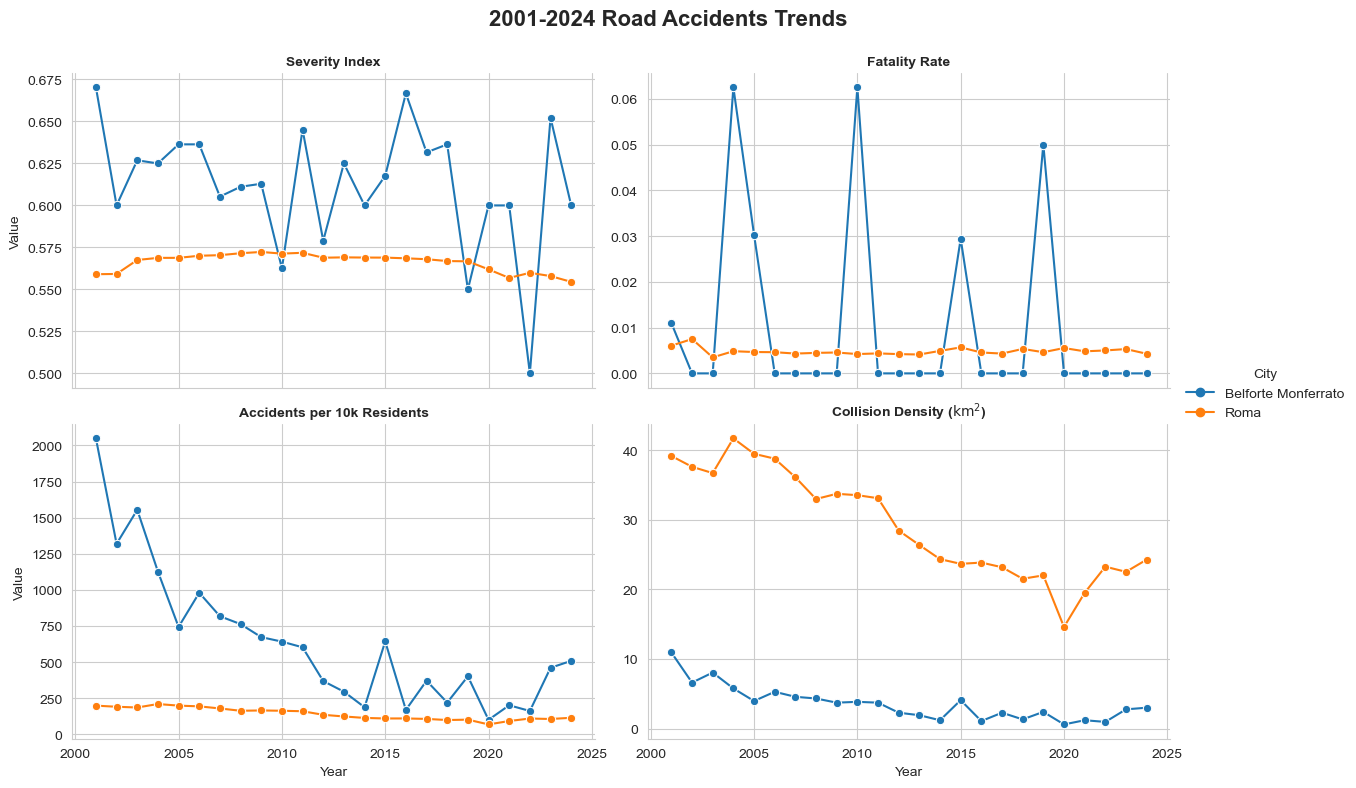

In [97]:
locations = ['Roma', 'Belforte Monferrato']

metrics = ['Severity_index', 'Fatality_Rate', 'Per_Capita_Accidents_Rate', 'Collision_Density']
metric_labels = {
    'Per_Capita_Accidents_Rate': 'Accidents per 10k Residents',
    'Severity_index': 'Severity Index',
    'Fatality_Rate': 'Fatality Rate',
    'Collision_Density': r'Collision Density ($\text{km}^2$)',
}
realplot_city_comparison(df_pivot[df_pivot['City'].isin(locations)], 'City', 'Year', metrics, metric_labels)

The first thing we can see from this plot is that, upon closer observation of per capita and collision density, the number of accidents in both cities decreased. There was also a slight decrease in the Severity Index and Fatality Rate, especially in Rome. This could be a sign that car safety regulations, road quality, and other general regulations have impacted the number of accidents over time.   
Of course, these are just initial hypotheses based on a small sample, so it’s impossible to provide a precise estimate of the trend. For example, let’s compare the major Italian cities to see if these trends are similar across them.

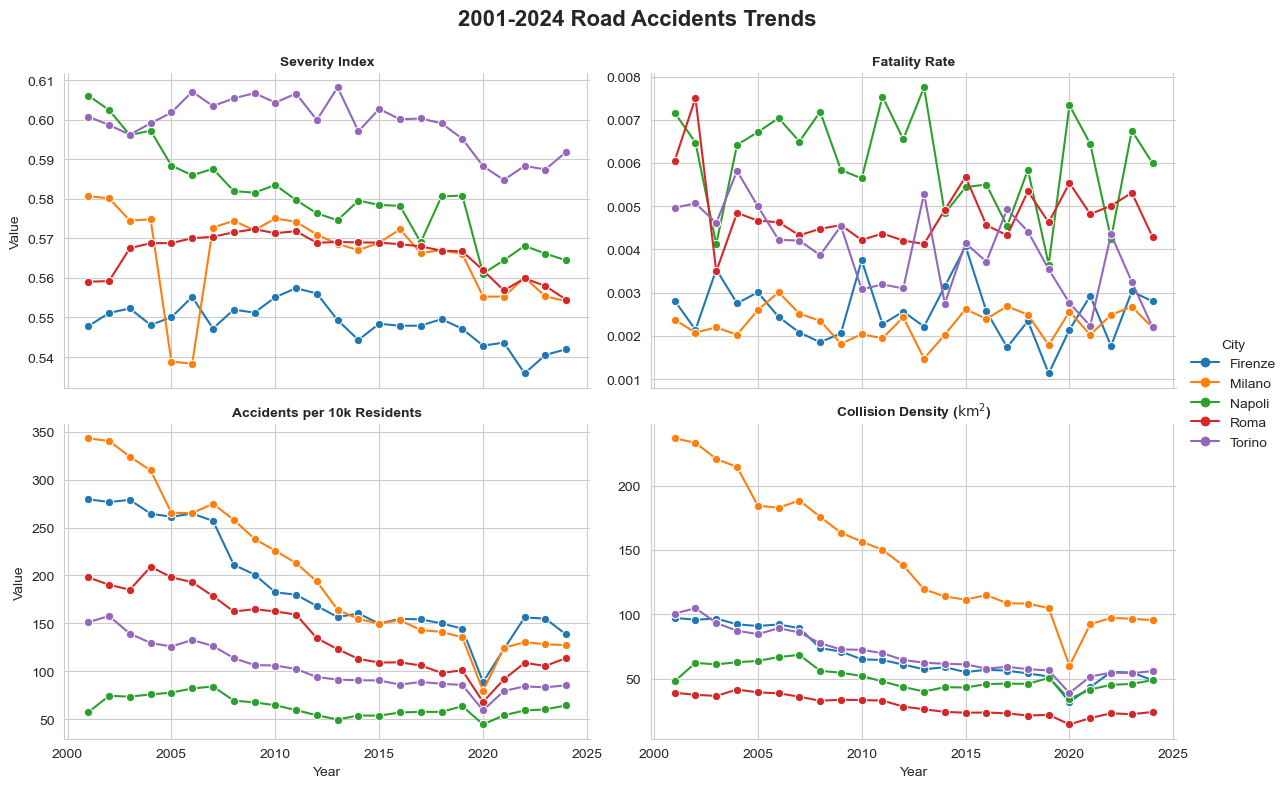

In [98]:
locations = ['Roma', 'Milano', 'Torino', 'Napoli', 'Firenze']

realplot_city_comparison(df_pivot[df_pivot['City'].isin(locations)], 'City', 'Year', metrics, metric_labels)

We can see some information from this graph:
- we can see that the trend described earlier, how the number of accidents has decreased over the years, also holds true for other major cities besides Rome.
- the number of accidents dropped dramatically in 2020; this is due to the COVID-19 pandemic and the lockdown, during which residents were largely unable to travel freely by car for much of that year. Therefore, 2020 should not be fully factored into our analysis, as it represents a very specific case and thus introduces a bias in our calculations.
- Among Italy’s most populous cities, Milan has the highest number of accidents (see per-capita and collision density), but it is also among those cities, along with Florence, where the vast majority of accidents are simple collisions.
In fact, cities like Turin, but especially Naples, have the lowest number of accidents yet the highest severity index and fatality rate, with Naples leading the latter.  
One possible explanation for these figures is that Milan, with its heavy traffic, experiences accidents that occur at low speeds, whereas in Naples, the high fatality rate may be caused by the widespread use of mopeds, which are far more dangerous than cars.

We can see that the downward trend in the number of accidents in Italy is consistent across regions as well, since, precisely because of the country’s geography, the terrain on which the roads are built can influence the number of accidents in Italy (Take Belforte Monferrato as an examplewhich is built on top of a hill).

In [78]:
# group by region
df_pivot_region = df_pivot.groupby(['Region', 'Year']).agg(
                                                        Sum_Residents=('Residents', 'sum'),
                                                        Region_Area=('Area (km2)', 'sum'),
                                                        Collision=('Collisions', 'sum'),
                                                        Injuries=('Injuries', 'sum'),
                                                        Fatalities=('Fatalities', 'sum'),
                                                        Total_Accidents=('Total_Accidents', 'sum')
                                                    ).reset_index()

# calculcate again the metrics
# 2) Harmful Accidents (M + F)
df_pivot_region['Harmful_Accidents'] = df_pivot_region['Fatalities'] + df_pivot_region['Injuries']

# 3) Severity Index (where condition to taking into account possible division by zero)
df_pivot_region['Severity_index'] = np.where(df_pivot_region['Total_Accidents'] > 0, df_pivot_region['Harmful_Accidents'] / df_pivot_region['Total_Accidents'], 0,)

# 4) Fatality Rate
df_pivot_region['Fatality_Rate'] = np.where(df_pivot_region['Total_Accidents'] > 0, df_pivot_region['Fatalities'] / df_pivot_region['Total_Accidents'], 0,)

# 5) Per-Capita Accidents Rate
df_pivot_region['Per_Capita_Accidents_Rate'] = (df_pivot_region['Total_Accidents'] / df_pivot_region['Sum_Residents']) * 1e4

# 6) Collision Density
df_pivot_region['Collision_Density'] = df_pivot_region['Total_Accidents'] / df_pivot_region['Region_Area']

df_pivot_region

,Region,Year,Sum_Residents,Region_Area,Collision,Injuries,Fatalities,Total_Accidents,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
0,Abruzzo,2001,1262187.0,10831.5397,5574.0,8342.0,168.0,14084.0,8510.0,0.604232,0.011928,111.584100,1.300277
1,Abruzzo,2002,1267633.0,10831.5370,5495.0,8496.0,185.0,14176.0,8681.0,0.612373,0.013050,111.830475,1.308771
2,Abruzzo,2003,1278658.0,10831.5370,5286.0,8066.0,154.0,13506.0,8220.0,0.608618,0.011402,105.626368,1.246914
3,Abruzzo,2004,1287157.0,10831.5370,4977.0,7544.0,141.0,12662.0,7685.0,0.606934,0.011136,98.371838,1.168994
4,Abruzzo,2005,1292999.0,10831.5370,4814.0,7225.0,134.0,12173.0,7359.0,0.604535,0.011008,94.145471,1.123848
...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Veneto,2020,4869830.0,18345.3694,9839.0,12919.0,229.0,22987.0,13148.0,0.571975,0.009962,47.202880,1.253014
476,Veneto,2021,4847745.0,18355.2293,12403.0,16512.0,285.0,29200.0,16797.0,0.575240,0.009760,60.234191,1.590827
477,Veneto,2022,4849553.0,18355.2293,13220.0,17286.0,321.0,30827.0,17607.0,0.571155,0.010413,63.566683,1.679467
478,Veneto,2023,4852216.0,18355.2293,12774.0,16994.0,309.0,30077.0,17303.0,0.575290,0.010274,61.986111,1.638607


To make our lives easier, we create a relplot for the grouped regions of North, Center, and South, which makes the plot much easier to read.

In [79]:
df_pivot_region['Region'].unique()

array(['Abruzzo', 'Basilicata', 'Calabria', 'Campania', 'Emilia-Romagna',
       'Friuli-Venezia Giulia', 'Lazio', 'Liguria', 'Lombardia', 'Marche',
       'Molise', 'Piemonte', 'Puglia', 'Sardegna', 'Sicilia', 'Toscana',
       'Trentino-Alto Adige/Südtirol', 'Umbria', "Valle d'Aosta",
       'Veneto'], dtype=object)

In [80]:
italian_regions_istat = {
    # Nord-Ovest
    "Piemonte": "North-West",
    "Valle d'Aosta": "North-West",
    "Lombardia": "North-West",
    "Liguria": "North-West",
    # Nord-Est
    "Trentino-Alto Adige": "North-East",
    "Veneto": "North-East",
    "Friuli-Venezia Giulia": "North-East",
    "Emilia-Romagna": "North-East",
    # Centro
    "Toscana": "Center",
    "Umbria": "Center",
    "Marche": "Center",
    "Lazio": "Center",
    # Sud e Isole
    "Abruzzo": "South",
    "Molise": "South",
    "Campania": "South",
    "Puglia": "South",
    "Basilicata": "South",
    "Calabria": "South",
    "Sicilia": "Islands",
    "Sardegna": "Islands",
}

df_pivot_region['Location'] = np.empty(df_pivot_region.shape[0], dtype=object)
df_pivot_region['Location'] = df_pivot_region['Region'].map(italian_regions_istat)
df_pivot_region

,Region,Year,Sum_Residents,Region_Area,Collision,Injuries,Fatalities,Total_Accidents,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density,Location
0,Abruzzo,2001,1262187.0,10831.5397,5574.0,8342.0,168.0,14084.0,8510.0,0.604232,0.011928,111.584100,1.300277,South
1,Abruzzo,2002,1267633.0,10831.5370,5495.0,8496.0,185.0,14176.0,8681.0,0.612373,0.013050,111.830475,1.308771,South
2,Abruzzo,2003,1278658.0,10831.5370,5286.0,8066.0,154.0,13506.0,8220.0,0.608618,0.011402,105.626368,1.246914,South
3,Abruzzo,2004,1287157.0,10831.5370,4977.0,7544.0,141.0,12662.0,7685.0,0.606934,0.011136,98.371838,1.168994,South
4,Abruzzo,2005,1292999.0,10831.5370,4814.0,7225.0,134.0,12173.0,7359.0,0.604535,0.011008,94.145471,1.123848,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Veneto,2020,4869830.0,18345.3694,9839.0,12919.0,229.0,22987.0,13148.0,0.571975,0.009962,47.202880,1.253014,North-East
476,Veneto,2021,4847745.0,18355.2293,12403.0,16512.0,285.0,29200.0,16797.0,0.575240,0.009760,60.234191,1.590827,North-East
477,Veneto,2022,4849553.0,18355.2293,13220.0,17286.0,321.0,30827.0,17607.0,0.571155,0.010413,63.566683,1.679467,North-East
478,Veneto,2023,4852216.0,18355.2293,12774.0,16994.0,309.0,30077.0,17303.0,0.575290,0.010274,61.986111,1.638607,North-East


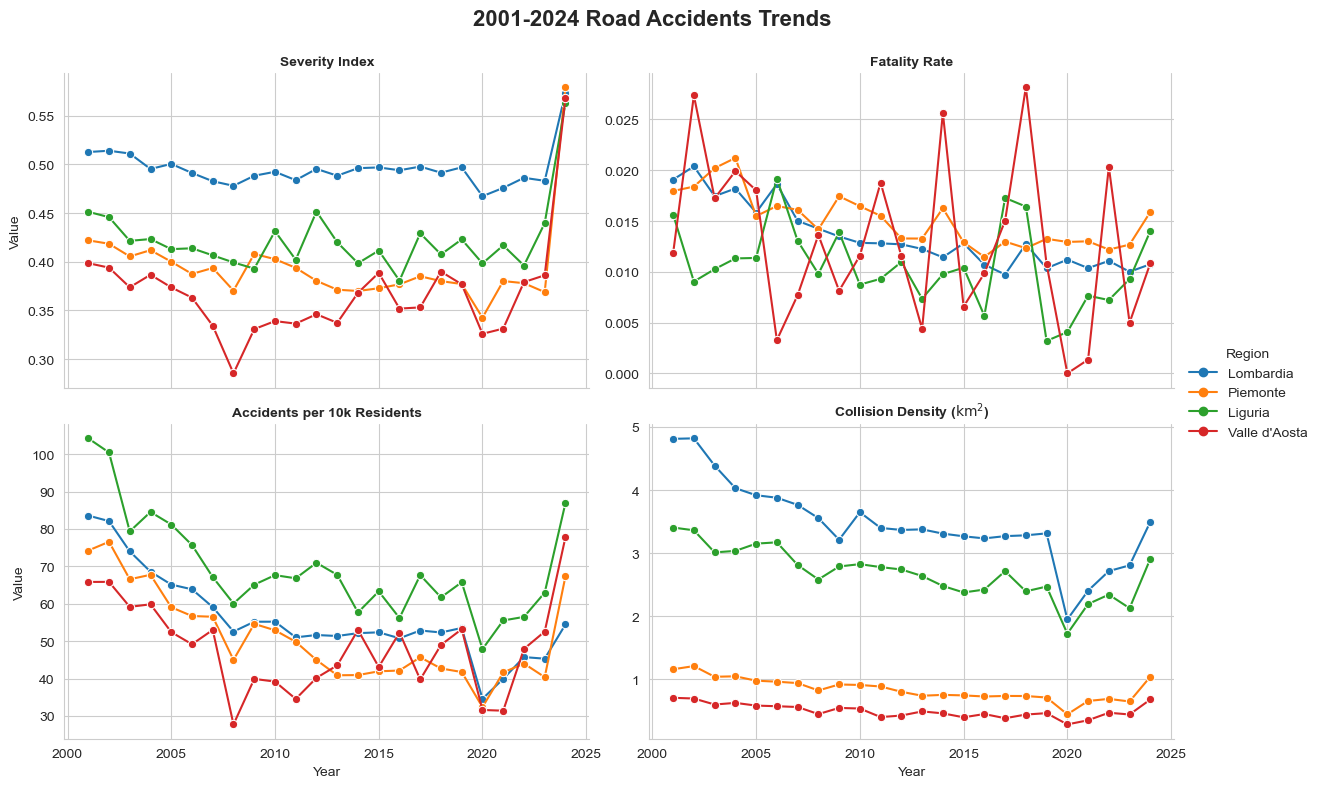

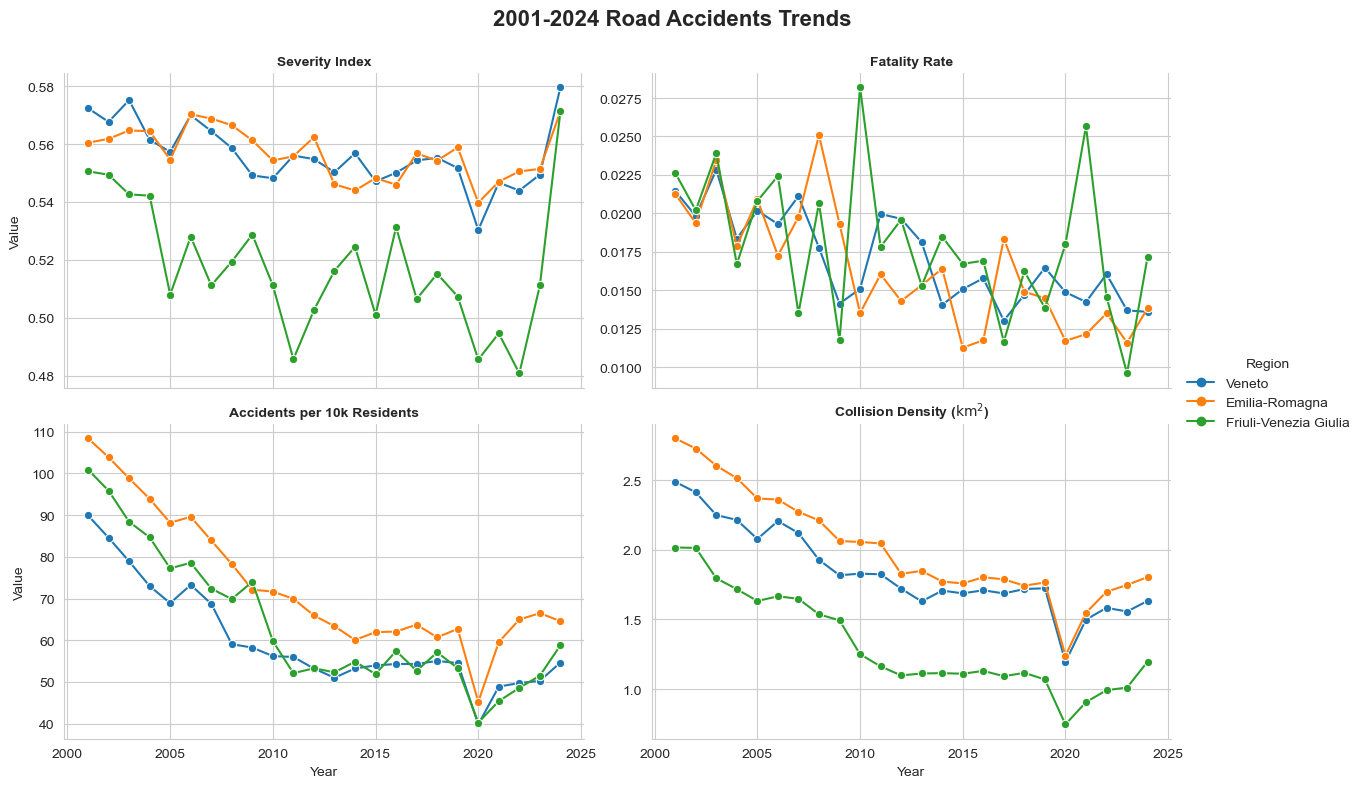

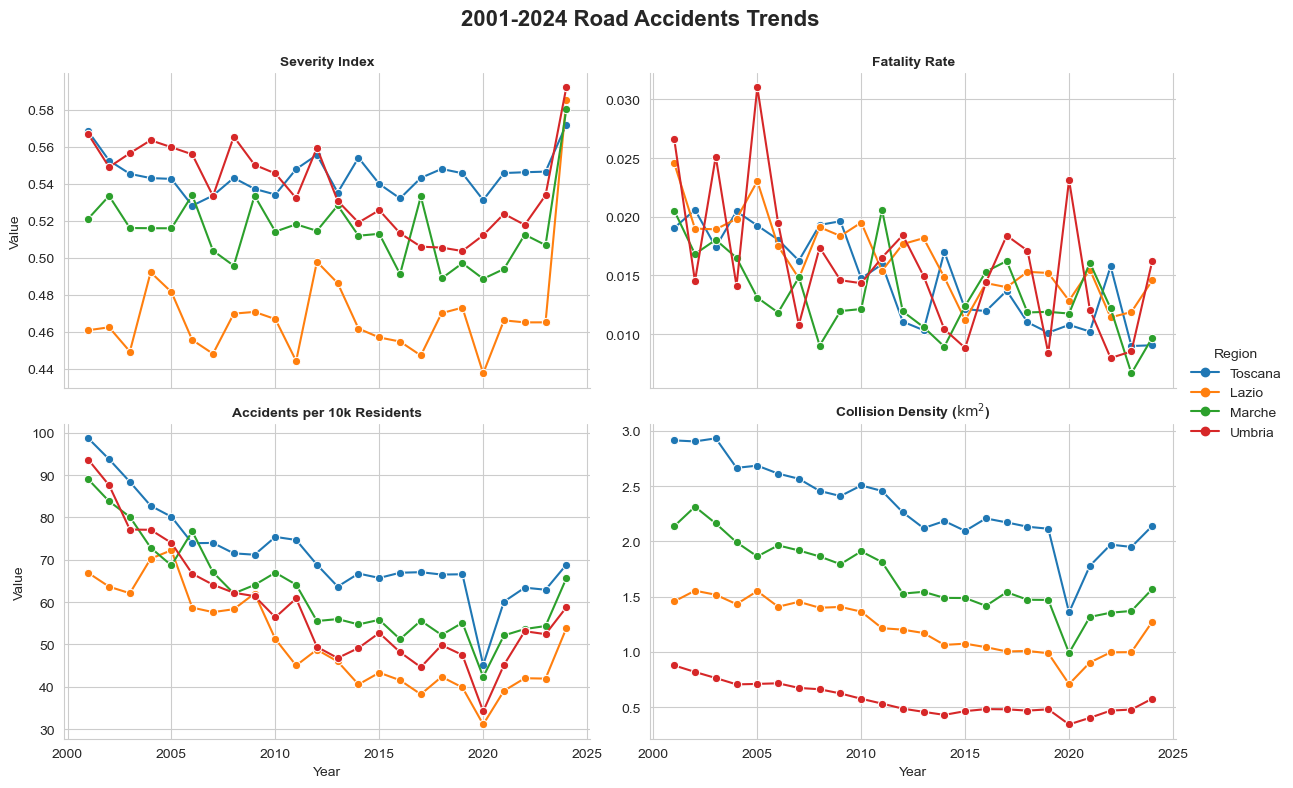

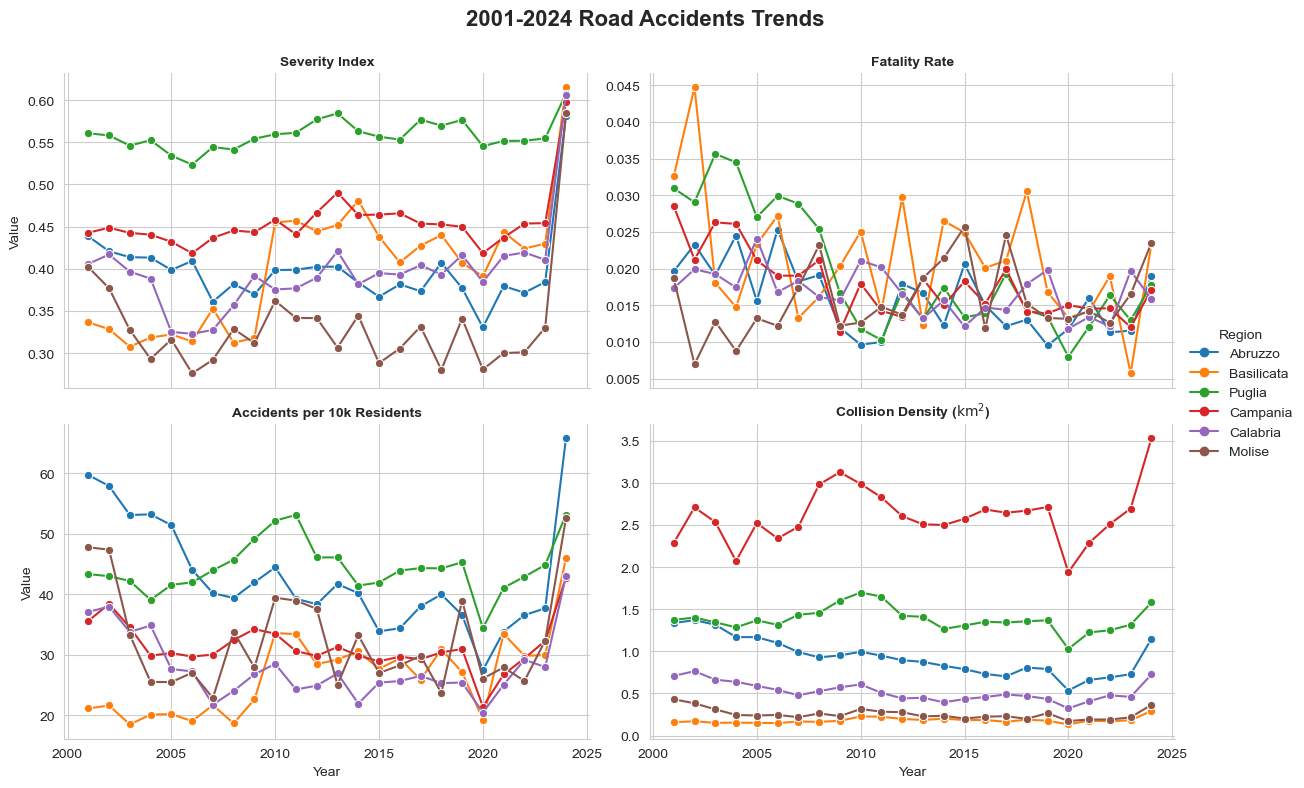

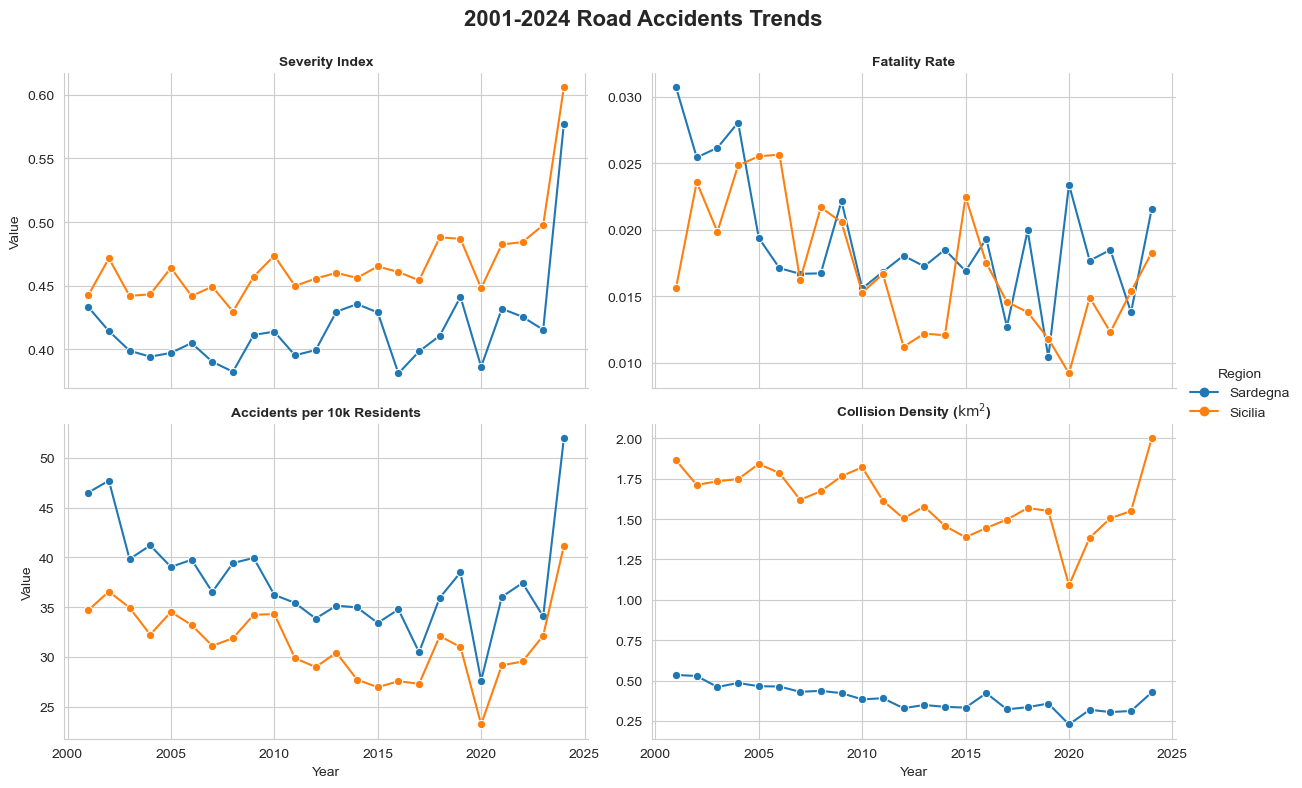

In [83]:
# North-West (Nord-Ovest)
north_west = ["Piemonte", "Valle d'Aosta", "Lombardia", "Liguria"]

# North-East (Nord-Est)
north_east = ["Trentino-Alto Adige", "Veneto", "Friuli-Venezia Giulia", "Emilia-Romagna",]

# Center (Centro)
center = ["Toscana", "Umbria", "Marche", "Lazio"]

# South (Sud)
south = ["Abruzzo", "Molise", "Campania", "Puglia", "Basilicata", "Calabria"]

# Islands
islands = ["Sicilia", "Sardegna"]

all_region = [north_west, north_east, center, south, islands]

for r in all_region:

    metrics = ['Severity_index', 'Fatality_Rate', 'Per_Capita_Accidents_Rate', 'Collision_Density']
    metric_labels = {
        'Per_Capita_Accidents_Rate': 'Accidents per 10k Residents',
        'Severity_index': 'Severity Index',
        'Fatality_Rate': 'Fatality Rate',
        'Collision_Density': r'Collision Density ($\text{km}^2$)',
    }

    realplot_city_comparison(df_pivot[df_pivot['Region'].isin(r)], 'Region', 'Year', metrics, metric_labels)

Looking at the graphs, but this time examining each region individually, we can see that the previously hypothesized trend of a decrease in the number of accidents over time does not always hold true, with the exception of 2020, when every region experienced a sharp drop caused by the lockdown. In particular, we see that in every region there is a peak in the number of serious accidents (severity index) in the year 2024, while the fatality rate is generally on the decline; therefore, one might hypothesize an increase in accidents resulting in injuries.  
In fact, it can be seen that the number of accidents after 2020 has increased, as evidenced by the collision density, which consistently shows a slight rise (assuming that the city’s area remains more or less constant).  

Based on this information, we can conclude that the number of accidents in Italian regions has increased significantly since 2020.
Since the purpose of this analysis is to determine where to focus efforts to invest in accident prevention now and in the future, the next step will be to identify the areas where the largest increase has occurred since 2020 (assuming that this increase will continue in the coming years).

## IDENTIFICATION